## Results of CPU and NPU for Ring-GNN



In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import glob
import os


## 1. 
First look at:
10 cross fold validation (90/10 split) running on the CPU

this is the original results from the paper:

Successfully loaded file!
   Epoch  Accuracy  Time (s)
0      0  0.684211  2.460812
1      1  0.684211  2.381780
2      2  0.842105  2.301772
3      3  0.736842  2.362073
4      4  0.789474  2.362270


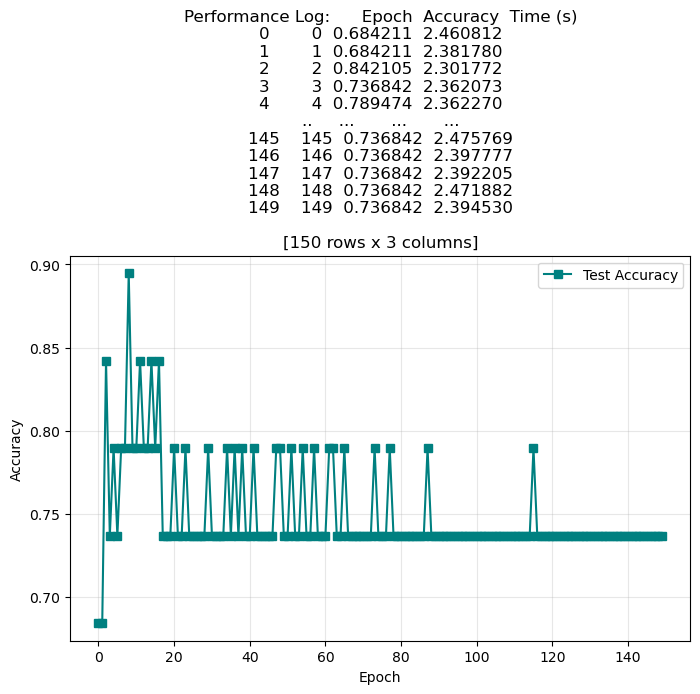

In [34]:
df1 = pd.read_csv('results/0730_mutag_0.csv')
    
# 2. Display the first few rows to verify headers
print("Successfully loaded file!")
print(df1.head())

# 3. Quick Plot of Accuracy
plt.figure(figsize=(8, 5))
plt.plot(df1['Epoch'], df1['Accuracy'], marker='s', color='teal', label='Test Accuracy')

plt.title(f'Performance Log: {df1}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [35]:
df1 = pd.read_csv('results/0730_mutag_0.csv')

avg_accuracy = df1['Accuracy'].mean()
print(f"Average Accuracy: {avg_accuracy:.4f}")

max_accuracy = df1['Accuracy'].max()
print(f"Max Accuracy: {max_accuracy:.4f}")

min_accuracy = df1['Accuracy'].min()
print(f"Min Accuracy: {min_accuracy:.4f} \n")

# repeat for time:

avg_latency = df1['Time (s)'].mean()
print(f"Average Latency: {avg_latency:.4f}")

max_latency = df1['Time (s)'].max()
print(f"Max Latency: {max_latency:.4f}")

min_latency = df1['Time (s)'].min()
print(f"Min Latency: {min_latency:.4f}")

Average Accuracy: 0.7495
Max Accuracy: 0.8947
Min Accuracy: 0.6842 

Average Latency: 2.3973
Max Latency: 2.5466
Min Latency: 2.2515


## 2.
10 cross fold validation (90/10 split) with bottleneck function ops_2_to_2 running on the NPU



Successfully loaded file!


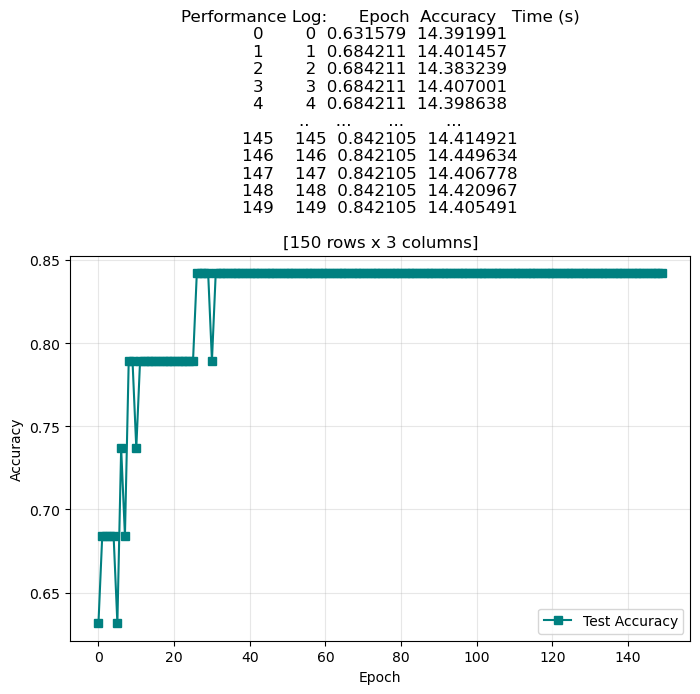

In [36]:
df2 = pd.read_csv('results/0731_NPU_test1_mutag_0.csv')
    
# 2. Display the first few rows to verify headers
print("Successfully loaded file!")
# print(df.head())

# 3. Quick Plot of Accuracy
plt.figure(figsize=(8, 5))
plt.plot(df2['Epoch'], df2['Accuracy'], marker='s', color='teal', label='Test Accuracy')

plt.title(f'Performance Log: {df2}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [37]:
df2 = pd.read_csv('results/0731_NPU_test1_mutag_0.csv')

avg_accuracy = df2['Accuracy'].mean()
print(f"Average Accuracy: {avg_accuracy:.4f}")

max_accuracy = df2['Accuracy'].max()
print(f"Max Accuracy: {max_accuracy:.4f}")

min_accuracy = df2['Accuracy'].min()
print(f"Min Accuracy: {min_accuracy:.4f} \n")

# repeat for time:

avg_latency = df2['Time (s)'].mean()
print(f"Average Latency: {avg_latency:.4f}")

max_latency = df2['Time (s)'].max()
print(f"Max Latency: {max_latency:.4f}")

min_latency = df2['Time (s)'].min()
print(f"Min Latency: {min_latency:.4f}")

Average Accuracy: 0.8263
Max Accuracy: 0.8421
Min Accuracy: 0.6316 

Average Latency: 14.4222
Max Latency: 14.4669
Min Latency: 14.3547


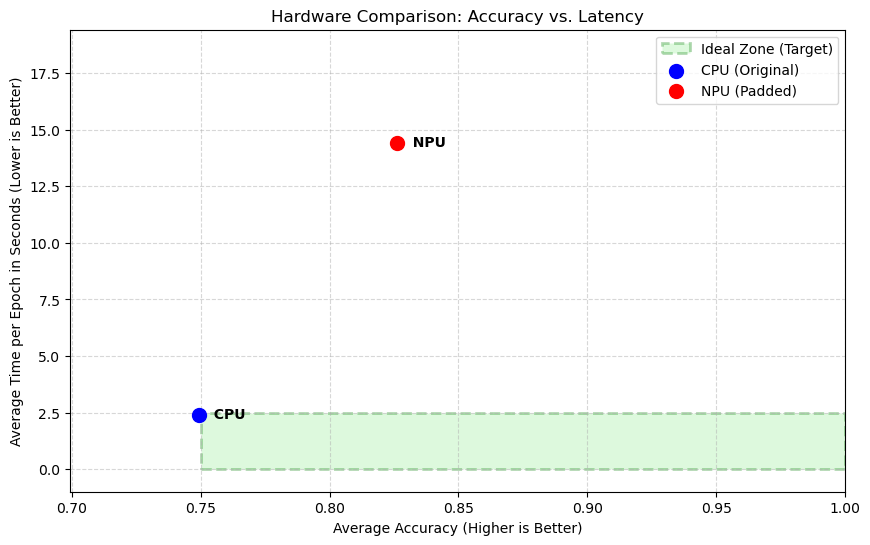

In [44]:
# 1. Calculate Averages
cpu_avg_acc = df1['Accuracy'].mean()
cpu_avg_time = df1['Time (s)'].mean()
npu_avg_acc = df2['Accuracy'].mean()
npu_avg_time = df2['Time (s)'].mean()

# 2. Create the Plot - THIS IS THE FIX
# We use subplots() to define both the figure (fig) and the axis (ax)
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Bonus - adding a square of ideal space:
ideal_x_start = 0.75  
ideal_y_start = 0     
ideal_width = 1.0 - ideal_x_start
ideal_height = 2.5    

ideal_zone = patches.Rectangle((ideal_x_start, ideal_y_start), 
                               ideal_width, ideal_height, 
                               linewidth=2, edgecolor='green', 
                               facecolor='#90EE90', alpha=0.3, 
                               linestyle='--', label='Ideal Zone (Target)')
ax.add_patch(ideal_zone)

# 4. Plot the points (using 'ax' instead of 'plt')
ax.scatter(cpu_avg_acc, cpu_avg_time, color='blue', s=100, label='CPU (Original)', zorder=5)
ax.scatter(npu_avg_acc, npu_avg_time, color='red', s=100, label='NPU (Padded)', zorder=5)

# 5. Add labels
ax.text(cpu_avg_acc + 0.002, cpu_avg_time, '  CPU', verticalalignment='center', fontweight='bold')
ax.text(npu_avg_acc + 0.002, npu_avg_time, '  NPU', verticalalignment='center', fontweight='bold')

# 6. Formatting the Grid
ax.set_title('Hardware Comparison: Accuracy vs. Latency')
ax.set_xlabel('Average Accuracy (Higher is Better)')
ax.set_ylabel('Average Time per Epoch in Seconds (Lower is Better)')

ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()

# 7. Set axes limits
ax.set_xlim(min(cpu_avg_acc, npu_avg_acc) - 0.05, 1.0) # Extended to 1.0 to show the whole Ideal Zone
ax.set_ylim(-1, max(cpu_avg_time, npu_avg_time) + 5)

plt.show()

## Batch testing

NPU batch testing to get better performance:

Successfully loaded file!
   Epoch  Accuracy   Time (s)
0      0  0.473684  15.747273
1      1  0.736842  15.866013
2      2  0.736842  15.931229
3      3  0.736842  15.939373
4      4  0.736842  15.805889


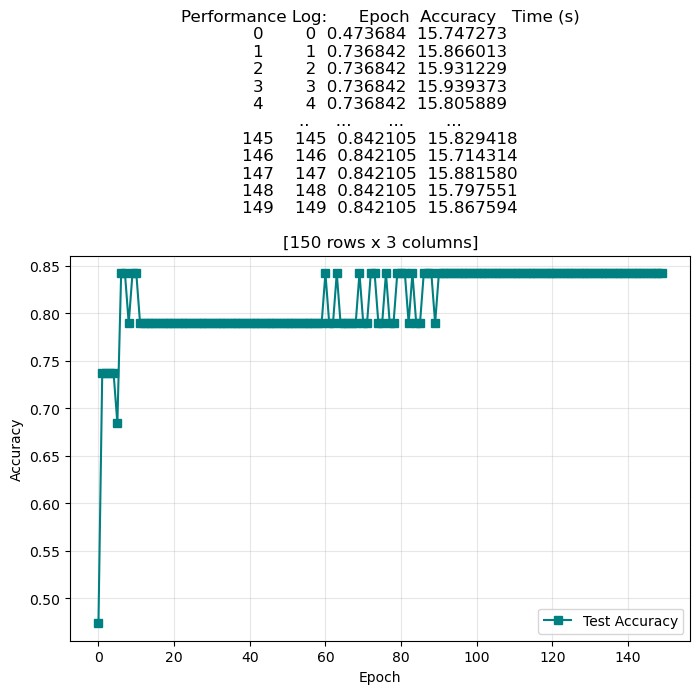

In [45]:
df3 = pd.read_csv('results/0732_NPU_test2_batch_mutag_0.csv')
    
# 2. Display the first few rows to verify headers
print("Successfully loaded file!")
print(df3.head())

# 3. Quick Plot of Accuracy
plt.figure(figsize=(8, 5))
plt.plot(df3['Epoch'], df3['Accuracy'], marker='s', color='teal', label='Test Accuracy')

plt.title(f'Performance Log: {df3}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [46]:
avg_accuracy = df3['Accuracy'].mean()
print(f"Average Accuracy: {avg_accuracy:.4f}")

max_accuracy = df3['Accuracy'].max()
print(f"Max Accuracy: {max_accuracy:.4f}")

min_accuracy = df3['Accuracy'].min()
print(f"Min Accuracy: {min_accuracy:.4f} \n")

# repeat for time:

avg_latency = df3['Time (s)'].mean()
print(f"Average Latency: {avg_latency:.4f}")

max_latency = df3['Time (s)'].max()
print(f"Max Latency: {max_latency:.4f}")

min_latency = df3['Time (s)'].min()
print(f"Min Latency: {min_latency:.4f}")

Average Accuracy: 0.8123
Max Accuracy: 0.8421
Min Accuracy: 0.4737 

Average Latency: 15.8139
Max Latency: 16.0410
Min Latency: 15.6723


## 4.
5 Cross Fold Validation on CPU

5 cross fold validation (80/20 split) running on the CPU



Successfully loaded file!
   Epoch  Accuracy  Time (s)
0      0  0.315789  1.880876
1      1  0.736842  1.791953
2      2  0.736842  1.799109
3      3  0.789474  1.858557
4      4  0.789474  1.810339


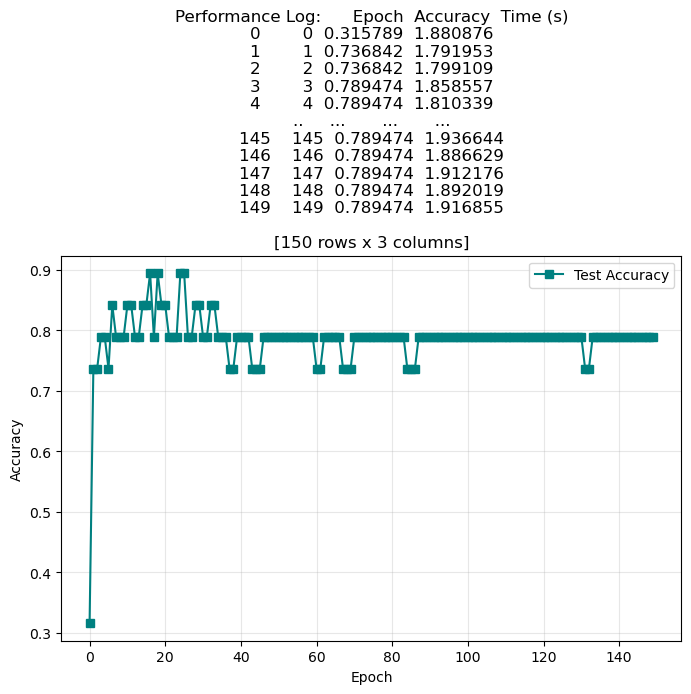

In [48]:
df4 = pd.read_csv('results/0734_CPU_padding_mutag_0.csv')
    
# 2. Display the first few rows to verify headers
print("Successfully loaded file!")
print(df4.head())

# 3. Quick Plot of Accuracy
plt.figure(figsize=(8, 5))
plt.plot(df4['Epoch'], df4['Accuracy'], marker='s', color='teal', label='Test Accuracy')

plt.title(f'Performance Log: {df4}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [49]:
avg_accuracy = df4['Accuracy'].mean()
print(f"Average Accuracy: {avg_accuracy:.4f}")

max_accuracy = df4['Accuracy'].max()
print(f"Max Accuracy: {max_accuracy:.4f}")

min_accuracy = df4['Accuracy'].min()
print(f"Min Accuracy: {min_accuracy:.4f} \n")

# repeat for time:

avg_latency = df4['Time (s)'].mean()
print(f"Average Latency: {avg_latency:.4f}")

max_latency = df4['Time (s)'].max()
print(f"Max Latency: {max_latency:.4f}")

min_latency = df4['Time (s)'].min()
print(f"Min Latency: {min_latency:.4f}")

Average Accuracy: 0.7867
Max Accuracy: 0.8947
Min Accuracy: 0.3158 

Average Latency: 1.8632
Max Latency: 2.1007
Min Latency: 1.7863


## 5.
5 Cross Fold Validation on NPU

5 cross fold validation (80/20 split) running on the NPU



Successfully loaded file!
   Epoch  Accuracy   Time (s)
0      0  0.710526  14.444647
1      1  0.842105  14.408399
2      2  0.842105  14.413782
3      3  0.894737  14.396188
4      4  0.868421  14.444501


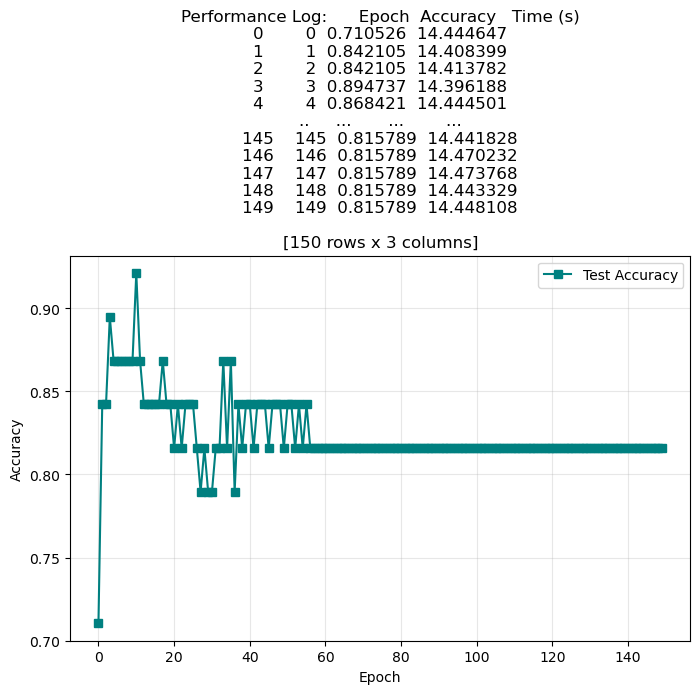

In [50]:
df5 = pd.read_csv('results/0733_NPU_5cross_mutag_0.csv')
    
# 2. Display the first few rows to verify headers
print("Successfully loaded file!")
print(df5.head())

# 3. Quick Plot of Accuracy
plt.figure(figsize=(8, 5))
plt.plot(df5['Epoch'], df5['Accuracy'], marker='s', color='teal', label='Test Accuracy')

plt.title(f'Performance Log: {df5}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [51]:
avg_accuracy = df5['Accuracy'].mean()
print(f"Average Accuracy: {avg_accuracy:.4f}")

max_accuracy = df5['Accuracy'].max()
print(f"Max Accuracy: {max_accuracy:.4f}")

min_accuracy = df5['Accuracy'].min()
print(f"Min Accuracy: {min_accuracy:.4f} \n")

# repeat for time:

avg_latency = df5['Time (s)'].mean()
print(f"Average Latency: {avg_latency:.4f}")

max_latency = df5['Time (s)'].max()
print(f"Max Latency: {max_latency:.4f}")

min_latency = df5['Time (s)'].min()
print(f"Min Latency: {min_latency:.4f}")

Average Accuracy: 0.8237
Max Accuracy: 0.9211
Min Accuracy: 0.7105 

Average Latency: 14.4315
Max Latency: 14.4756
Min Latency: 14.3872


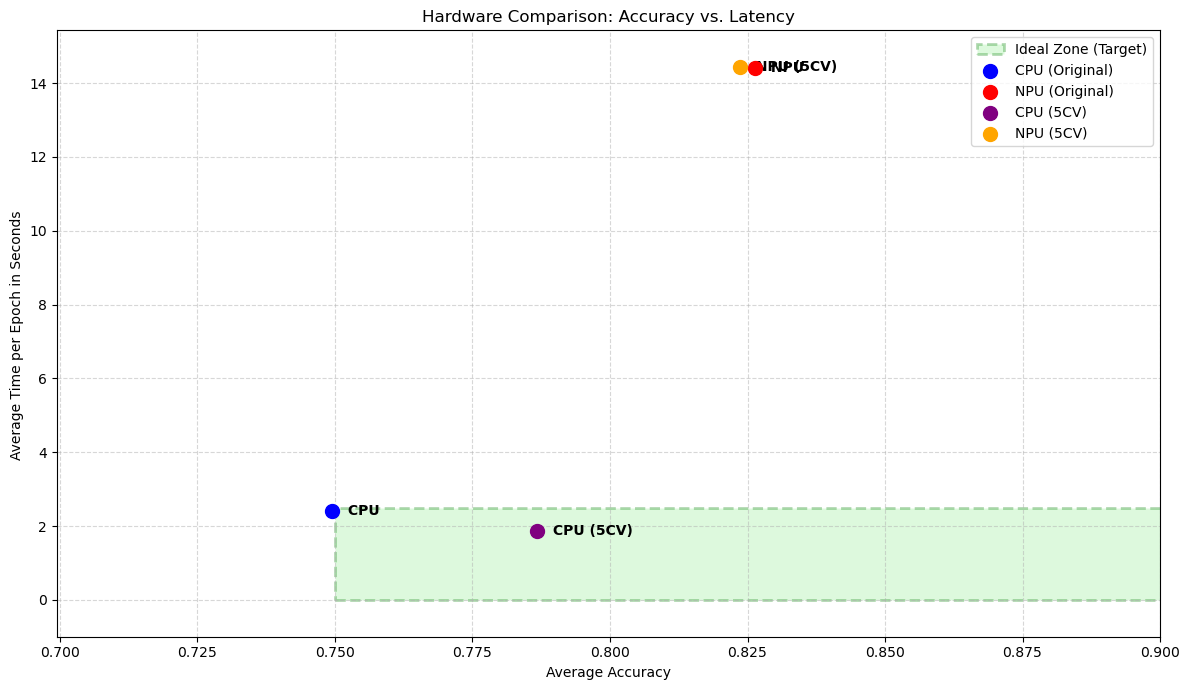

In [62]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Calculate Averages for the original 2
cpu_avg_acc = df1['Accuracy'].mean()
cpu_avg_time = df1['Time (s)'].mean()
npu_avg_acc = df2['Accuracy'].mean()
npu_avg_time = df2['Time (s)'].mean()


#CPU 5 cross validation
b_avg_acc = df4['Accuracy'].mean()
b_avg_time = df4['Time (s)'].mean()

#NPU 5 cross fold validation
c_avg_acc = df5['Accuracy'].mean()
c_avg_time = df5['Time (s)'].mean()

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(12, 7))

# 4. The Ideal Zone Square
ideal_x_start = 0.75  
ideal_y_start = 0     
ideal_width = 1.0 - ideal_x_start
ideal_height = 2.5    

ideal_zone = patches.Rectangle((ideal_x_start, ideal_y_start), 
                               ideal_width, ideal_height, 
                               linewidth=2, edgecolor='green', 
                               facecolor='#90EE90', alpha=0.3, 
                               linestyle='--', label='Ideal Zone (Target)')
ax.add_patch(ideal_zone)

# 5. Plot the 5 Points
# Original 2
ax.scatter(cpu_avg_acc, cpu_avg_time, color='blue', s=100, label='CPU (Original)', zorder=5)
ax.scatter(npu_avg_acc, npu_avg_time, color='red', s=100, label='NPU (Original)', zorder=5)

# New 3 Points (A, B, C)
ax.scatter(b_avg_acc, b_avg_time, color='purple', s=100, label='CPU (5CV)', zorder=5)
ax.scatter(c_avg_acc, c_avg_time, color='orange', s=100, label='NPU (5CV)', zorder=5)

# 6. Add Text Labels
ax.text(cpu_avg_acc + 0.002, cpu_avg_time, ' CPU', verticalalignment='center', fontweight='bold')
ax.text(npu_avg_acc + 0.002, npu_avg_time, ' NPU', verticalalignment='center', fontweight='bold')
ax.text(b_avg_acc + 0.002, b_avg_time, ' CPU (5CV)', verticalalignment='center', fontweight='bold')
ax.text(c_avg_acc + 0.002, c_avg_time, ' NPU (5CV)', verticalalignment='center', fontweight='bold')

# 7. Formatting the Grid
ax.set_title('Hardware Comparison: Accuracy vs. Latency')
ax.set_xlabel('Average Accuracy')
ax.set_ylabel('Average Time per Epoch in Seconds ')

ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# 8. Dynamic Axis Limits
# Finds the min/max of all accuracy and time values to ensure all 5 points are visible
all_accs = [cpu_avg_acc, npu_avg_acc,  b_avg_acc, c_avg_acc]
all_times = [cpu_avg_time, npu_avg_time,  b_avg_time, c_avg_time]

ax.set_xlim(min(all_accs) - 0.05, 0.9) 
ax.set_ylim(-1, max(all_times) + 1)



plt.tight_layout()
plt.show()